Este notebook es el que usaremos para poder entrenar especificamente los modelos en base al dataset que vamos a usar que es el de libros, de este notebook van a salir las graficas que usaremos para el front end, y las funciones 

Nos vamos a centrar en completar una primera fase que seria preprocesar el dataset de libros:
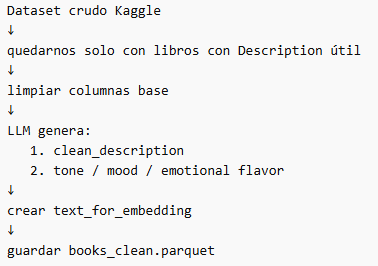

Para los embeddings vamos a juntar el titulo, la descripcion y la categoria, solo que en este caso usaremos una descripcion creada por un LLM mas limpia que la original y mas pequena, vamos a generar un Mood Label o Tone label tambien.

In [33]:
pip install kagglehub pandas numpy pyarrow tqdm openai tenacity -q

Note: you may need to restart the kernel to use updated packages.


Dataset que usaremos: https://www.kaggle.com/datasets/elvinrustam/books-dataset

# **Fase 1: Preprocessing de Dataset**

Bajamos el dataset de kaggle y definimos algunos imports

In [34]:
import os
import json
import glob
import re
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import kagglehub

DATASET_ID = "elvinrustam/books-dataset"

path = kagglehub.dataset_download(DATASET_ID)
print("Dataset path:", path)

files = glob.glob(os.path.join(path, "**", "*"), recursive=True)
for f in files[:30]:
    print(f)

Dataset path: C:\Users\user\.cache\kagglehub\datasets\elvinrustam\books-dataset\versions\3
C:\Users\user\.cache\kagglehub\datasets\elvinrustam\books-dataset\versions\3\BooksDataset.csv
C:\Users\user\.cache\kagglehub\datasets\elvinrustam\books-dataset\versions\3\BooksDatasetClean.csv


Crear el csv con el dataset que bajamos de kaggle, para este caso kaggle traia 2 uno clean y uno raw que son lo mismo en informacion solo que la fecha esta procesada diferente y el precio


In [35]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import os
import json

dataset_path = Path(path)

clean_csv = dataset_path / "BooksDatasetClean.csv"

df_raw = pd.read_csv(clean_csv)

print("Using:", clean_csv)
print("Shape:", df_raw.shape)
df_raw.head()

Using: C:\Users\user\.cache\kagglehub\datasets\elvinrustam\books-dataset\versions\3\BooksDatasetClean.csv
Shape: (103063, 8)


,Title,Authors,Description,Category,Publisher,Price Starting With ($),Publish Date (Month),Publish Date (Year)
0,Goat Brothers,"By Colton, Larry",NaN,"History , General",Doubleday,8.79,January,1993
1,The Missing Person,"By Grumbach, Doris",NaN,"Fiction , General",Putnam Pub Group,4.99,March,1981
2,Don't Eat Your Heart Out Cookbook,"By Piscatella, Joseph C.",NaN,"Cooking , Reference",Workman Pub Co,4.99,September,1983
3,When Your Corporate Umbrella Begins to Leak: A Handbook for White Collar Re-Employment,"By Davis, Paul D.",NaN,NaN,Natl Pr Books,4.99,April,1991
4,Amy Spangler's Breastfeeding : A Parent's Guide,"By Spangler, Amy",NaN,NaN,Amy Spangler,5.32,February,1997


Vamos a normalizar los nombres de las columnas para no tener espacios y mayusculas y no batallar 

In [36]:
df = df_raw.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("$", "usd", regex=False)
)

print(df.columns.tolist())
df.head()

['title', 'authors', 'description', 'category', 'publisher', 'price_starting_with_usd', 'publish_date_month', 'publish_date_year']


,title,authors,description,category,publisher,price_starting_with_usd,publish_date_month,publish_date_year
0,Goat Brothers,"By Colton, Larry",NaN,"History , General",Doubleday,8.79,January,1993
1,The Missing Person,"By Grumbach, Doris",NaN,"Fiction , General",Putnam Pub Group,4.99,March,1981
2,Don't Eat Your Heart Out Cookbook,"By Piscatella, Joseph C.",NaN,"Cooking , Reference",Workman Pub Co,4.99,September,1983
3,When Your Corporate Umbrella Begins to Leak: A Handbook for White Collar Re-Employment,"By Davis, Paul D.",NaN,NaN,Natl Pr Books,4.99,April,1991
4,Amy Spangler's Breastfeeding : A Parent's Guide,"By Spangler, Amy",NaN,NaN,Amy Spangler,5.32,February,1997


Definimos las columnas principales, para tenerlas en variable

In [37]:
COL_TITLE = "title"
COL_AUTHORS = "authors"
COL_DESC = "description"
COL_CATEGORY = "category"
COL_PUBLISHER = "publisher"
COL_PRICE = "price_starting_with_usd"
COL_MONTH = "publish_date_month"
COL_YEAR = "publish_date_year"

Aqui vamos a implementar una limpieza basica del texto, quitar espacios repetidos, html, etc.

In [38]:
def clean_basic_text(x):
    if pd.isna(x):
        return ""
    
    x = str(x)
    x = re.sub(r"<.*?>", " ", x)          # quitar HTML
    x = re.sub(r"\s+", " ", x).strip()    # espacios repetidos
    return x

df["title_clean"] = df[COL_TITLE].apply(clean_basic_text)
df["authors_clean"] = df[COL_AUTHORS].apply(clean_basic_text)
df["description_original_clean"] = df[COL_DESC].apply(clean_basic_text)
df["category_clean"] = df[COL_CATEGORY].apply(clean_basic_text)
df["publisher_clean"] = df[COL_PUBLISHER].apply(clean_basic_text)

df[[
    "title_clean",
    "authors_clean",
    "description_original_clean",
    "category_clean",
    "publisher_clean"
]].head()

,title_clean,authors_clean,description_original_clean,category_clean,publisher_clean
0,Goat Brothers,"By Colton, Larry",,"History , General",Doubleday
1,The Missing Person,"By Grumbach, Doris",,"Fiction , General",Putnam Pub Group
2,Don't Eat Your Heart Out Cookbook,"By Piscatella, Joseph C.",,"Cooking , Reference",Workman Pub Co
3,When Your Corporate Umbrella Begins to Leak: A Handbook for White Collar Re-Employment,"By Davis, Paul D.",,,Natl Pr Books
4,Amy Spangler's Breastfeeding : A Parent's Guide,"By Spangler, Amy",,,Amy Spangler


Ahora lo importante, vamos a solo quedarnos con libros que tienen una descripcion util, no nulos, no si no tienen nada, etc. Porque para este problema necesitamos que los libros tengan descripcion porque lo necesitamos para la core function de nuestro sistema, para que los embeddings tengan sentido, y a parte se las pasaremos a un LLM para que nos cree una descripcion mas limpia y compacta, y no le podemos pasar valores nulos.

In [39]:
# -----------------------------
# Required field validation
# -----------------------------

bad_required_patterns = [
    r"^\s*$",
    r"^null$",
    r"^none$",
    r"^nan$",
    r"^unknown$",
    r"^n/a$",
    r"^na$",
    r"not available"
]

bad_required_regex = re.compile("|".join(bad_required_patterns), re.IGNORECASE)

bad_description_patterns = [
    r"^\s*$",
    r"^null$",
    r"^none$",
    r"^nan$",
    r"^unknown$",
    r"^n/a$",
    r"^na$",
    r"for ingest only",
    r"description unavailable",
    r"no description",
    r"not available"
]

bad_description_regex = re.compile("|".join(bad_description_patterns), re.IGNORECASE)


def clean_category_text(x):
    x = clean_basic_text(x)
    x = re.sub(r"\s*,\s*", ", ", x)   # "Fiction , General" -> "Fiction, General"
    x = re.sub(r"\s+", " ", x).strip()
    return x


def is_valid_required_text(x):
    if not x:
        return False
    
    if bad_required_regex.search(x):
        return False
    
    return True


def is_valid_description(desc, min_chars=80):
    if not desc:
        return False
    
    if bad_description_regex.search(desc):
        return False
    
    if len(desc) < min_chars:
        return False
    
    alpha_count = sum(ch.isalpha() for ch in desc)
    if alpha_count < 40:
        return False
    
    return True


# Clean category format before filtering
df["category_clean"] = df["category_clean"].apply(clean_category_text)

before = len(df)

df = df[
    df["title_clean"].apply(is_valid_required_text) &
    df["category_clean"].apply(is_valid_required_text) &
    df["description_original_clean"].apply(is_valid_description)
].copy()

after = len(df)

print("Rows before filtering:", before)
print("Rows after filtering:", after)
print("Rows removed:", before - after)
print("Remaining percentage:", round(after / before * 100, 2), "%")

Rows before filtering: 103063
Rows after filtering: 64620
Rows removed: 38443
Remaining percentage: 62.7 %


Vamos a limpiar los libros que tengan datos como Unkown, para despues descartarlos tambien

In [40]:
# -----------------------------
# Optional metadata for frontend display
# -----------------------------

def display_value(x):
    if pd.isna(x):
        return ""
    
    x = str(x).strip()
    
    if x.lower() in ["", "nan", "none", "null", "unknown", "n/a", "na"]:
        return ""
    
    return x


df["authors_display"] = df["authors_clean"].apply(display_value)
df["publisher_display"] = df["publisher_clean"].apply(display_value)
df["price_display"] = df[COL_PRICE].apply(display_value)
df["publish_month_display"] = df[COL_MONTH].apply(display_value)
df["publish_year_display"] = df[COL_YEAR].apply(display_value)

df[[
    "title_clean",
    "authors_display",
    "category_clean",
    "publisher_display",
    "price_display",
    "publish_month_display",
    "publish_year_display"
]].head()

,title_clean,authors_display,category_clean,publisher_display,price_display,publish_month_display,publish_year_display
7,Journey Through Heartsongs,"By Stepanek, Mattie J. T.","Poetry, General",VSP Books,19.96,September,2001
8,In Search of Melancholy Baby,"By Aksyonov, Vassily, Heim, Michael Henry, and Bouis, Antonina W.","Biography & Autobiography, General",Random House,4.99,June,1987
10,The Dieter's Guide to Weight Loss During Sex,"By Smith, Richard","Health & Fitness, Diet & Nutrition, Diets",Workman Publishing Company,4.99,January,1978
11,Germs : Biological Weapons and America's Secret War,"By Miller, Judith, Engelberg, Stephen, and Broad, William J.","Technology & Engineering, Military Science",Simon & Schuster,4.99,October,2001
13,The Good Book: Reading the Bible with Mind and Heart,"By Gomes, Peter J.","Religion, Biblical Biography, General",Harper Perennial,5.29,May,1998


Quitamos los registros que esten duplicados

In [42]:
before = len(df)

df = df.drop_duplicates(
    subset=["title_clean", "authors_clean", "description_original_clean"]
).reset_index(drop=True)

after = len(df)

print("Rows before duplicates:", before)
print("Rows after duplicates:", after)
print("Duplicates removed:", before - after)

Rows before duplicates: 64620
Rows after duplicates: 64243
Duplicates removed: 377


Hacemos un sanity check para ver que no tengamos registros malos o sin texto en los campos de Title, Description y Categories porque son los unicos 3 que importan para los embeddings, todos los demas pueden estar incompletos no importa mucho, solamente no van a salir en el Hover del mapa y ya.

In [47]:
print("Total rows after duplicates:", len(df))

print("Empty titles:", (df["title_clean"] == "").sum())
print("Empty categories:", (df["category_clean"] == "").sum())
print("Empty descriptions:", (df["description_original_clean"] == "").sum())

bad_values = ["unknown", "null", "none", "nan", "n/a", "na", ""]

print("Bad titles:", df["title_clean"].str.lower().isin(bad_values).sum())
print("Bad categories:", df["category_clean"].str.lower().isin(bad_values).sum())
print("Bad descriptions:", df["description_original_clean"].str.lower().isin(bad_values).sum())

Total rows after duplicates: 64243
Empty titles: 0
Empty categories: 0
Empty descriptions: 0
Bad titles: 0
Bad categories: 0
Bad descriptions: 0


Ahora si vamos a visualizar algunos ejemplos de descripciones para poder ver si son muy largas, o con que estamos trabajando, para ver si es necesario pasarselas a un LLM para que nos cree la version clean. 

In [43]:
pd.set_option("display.max_colwidth", 700)

sample = df[[
    "title_clean",
    "authors_clean",
    "category_clean",
    "description_original_clean"
]].sample(4, random_state=42)

sample

,title_clean,authors_clean,category_clean,description_original_clean
31256,"The Monitor: Civil War Battleship, Level 4","By Day, Larry (ILT) and Thompson, Gare","Juvenile Fiction, Readers, Beginner","The U.S.S. Monitor was an entirely new type of warship when it launched in 1862. Dubbed ""the forefather of the modern Navy,"" this ironclad ship changed how wars are fought at sea. But on New Year's Eve, 1862, it sank off the coast of North Carolina in a terrible storm. No one thought the Monitor could be raised, but after 140 years, parts of the ironclad have finally been brought to the surface. This book chronicles the Monitor's revolutionary design, exciting battle, and intriguing excavation.Illustrated by Larry Day."
7167,TV Guide: Fifty Years of Television,"By Lasswell, Mark","Performing Arts, Television, General","More than 350 full-color and black-and-white photographs from the archive of TV Guide celebrate a half century of television history, from The Howdy Doody Show and I Love Lucy to The Simpsons and The Sopranos, and the personalities, shows, and landmark events that changed entertainment history. 150,000 first printing."
53797,Moments of Peace in the Presence of God,By Baker Publishing Group,"Religion, Meditations","Wisdom and inspiration from the Psalms come to life anew in this collection of more than 170 meditations. Each two-page spread presents a devotional thought and encouraging Scriptures. The unique crafting and blending of words and illustrations ensures appeal to Christians young and old. Ideal for year-round gift-giving--including Mother's Day, Father's Day, and graduations."
60930,I Wish This War Were over,"By O'Hehir, Diana","Fiction, Literary","Nineteen-year-old Helen Reynolds, journeying cross-country by train as America enters World War II, meets and is bewitched by John O'Connell, a former suitor of her mother, the sad, beautiful, alcoholic Selma"


Si, definitivamente las descripciones son muy largas, necesitamos pasarselas a un LLM para que nos la normalize creandonos descripciones con un limite de palabras, compactas pero que aun asi capture la esencia del texto para que quede bien para los embeddings.

Vamos a ver la distribucion de las descripciones

In [44]:
df["description_length"] = df["description_original_clean"].str.len()

df["description_length"].describe()

count    64243.000000
mean       770.036922
std        654.561322
min         80.000000
25%        240.000000
50%        632.000000
75%       1091.000000
max      23502.000000
Name: description_length, dtype: float64

In [45]:
df[[
    "title_clean",
    "category_clean",
    "description_length",
    "description_original_clean"
]].sort_values("description_length").head(3)

,title_clean,category_clean,description_length,description_original_clean
25620,In God We Trust: A Positive Faith for Troubled Times,"Religion, Inspirational",80,"Relates ways of building a better, more positive life through the power of faith"
35371,First Words (Baby Genius),"Juvenile Nonfiction, Concepts, General",80,Book for young children increases vocabulary by associating words with pictures.
24611,Con Mi Hermano / With My Brother,"Juvenile Fiction, People & Places, United States, Hispanic & Latino",80,A little boy admires his big brother and aspires to be like him when he is older


In [46]:
df[[
    "title_clean",
    "category_clean",
    "description_length",
    "description_original_clean"
]].sort_values("description_length", ascending=False).head(3)

,title_clean,category_clean,description_length,description_original_clean
40253,Blood of Paradise,"Fiction, General",23502,"El Salvador: America’s great Cold War success story and the model for Iraq’s fledgling democracy–if one ignores the grinding poverty, the corruption, the spiraling crime, and a murder rate ranked near the top in the hemisphere. This is where Jude McManus works as an executive protection specialist, currently assigned to an American engineer working for a U.S. consortium.Ten years before, at age seventeen, he saw his father and two Chicago cop colleagues arrested for robbing street dealers. The family fell apart in the scandal’s wake, his disgraced dad died under suspicious circumstances, and Jude fled Chicago to join the army and forge a new life.Now the past returns when one of his fath..."
6113,The Sixteen Pleasures: A Novel,"Fiction, Historical, General",14977,"Chapter OneWhere I Want to BeI was twenty-nine years old when the Arno flooded its banks on Friday 4 November 1966. According to the Sunday New York Times the damage wasn't extensive, but by Monday it was clear that Florence was a disaster. Twenty feet of water in the cloisters of Santa Croce, the Cimabue crucifix ruined beyond hope of restoration, panels ripped from the Baptistry doors, the basement of the Biblioteca Nazionale completely underwater, hundreds of thousands of volumes waterlogged, the Archivio di Stato in total disarray. On Tuesday I decided to go to Italy, to offer my services as a humble book conservator, to help in any way I could, to save whatever could be saved, inclu..."
18356,An Accidental American: A Novel (Mortalis),"Fiction, Thrillers, General",12456,"Forced out of a self-imposed exile, one woman faces a lifetime’s worth of secrets and betrayal–all in the name of staying alive. Nicole Blake had planned to leave her criminal life in the past. She had done her time in a dank prison in Marseille and relinquished the world of forgery and counterfeiting for an unassuming career as a freelance consultant. Now her world is a small farm in the French Pyrenees, with daily fresh eggs and the companionship of her devoted dog.But when U.S. intelligence operative John Valsamis shows up at her door, Nicole is reminded that she’ll always be an ex-con. Valsamis is after Nicole’s former lover, Rahim Ali, and soon Nicole finds herself back in Lisbon, t..."


Guardamos el Processed dataset que tenemos, para pasar ahora a la siguiente fase

In [48]:
from pathlib import Path

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

preprocessed_path = ARTIFACTS_DIR / "books_preprocessed_before_llm.parquet"

df.to_parquet(preprocessed_path, index=False)

print("Saved:", preprocessed_path)
print("Shape:", df.shape)

Saved: artifacts\books_preprocessed_before_llm.parquet
Shape: (64243, 19)


# **Fase 2: Usar LLM para generar mood label y una descripcion compacta que usaremos para Embeddings**

Cargamos el dataset preprocesado directamente del .parquet file que tenemos en artifacts

In [51]:
from pathlib import Path
import pandas as pd
import json
import os
from tqdm.auto import tqdm

ARTIFACTS_DIR = Path("artifacts")

df = pd.read_parquet(ARTIFACTS_DIR / "books_preprocessed_before_llm.parquet")

print(df.shape)
df.head(1)

(64243, 19)


,title,authors,description,category,publisher,price_starting_with_usd,publish_date_month,publish_date_year,title_clean,authors_clean,description_original_clean,category_clean,publisher_clean,authors_display,publisher_display,price_display,publish_month_display,publish_year_display,description_length
0,Journey Through Heartsongs,"By Stepanek, Mattie J. T.","Collects poems written by the eleven-year-old muscular dystrophy patient, sharing his feelings and thoughts about his life, the deaths of his siblings, nature, faith, and hope.","Poetry , General",VSP Books,19.96,September,2001,Journey Through Heartsongs,"By Stepanek, Mattie J. T.","Collects poems written by the eleven-year-old muscular dystrophy patient, sharing his feelings and thoughts about his life, the deaths of his siblings, nature, faith, and hope.","Poetry, General",VSP Books,"By Stepanek, Mattie J. T.",VSP Books,19.96,September,2001,176


Ahora vamos a definir los tone options que va a tener el LLM para elegir 


In [ ]:
TONE_OPTIONS = [
    "Dark",
    "Suspenseful",
    "Mysterious",
    "Romantic",
    "Uplifting",
    "Reflective",
    "Melancholic",
    "Adventurous",
    "Humorous",
    "Whimsical",
    "Inspiring",
    "Informative",
    "Serious",
    "Emotional",
    "Neutral"
]